<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES17Sim003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

dt: 1.900e-02, beta_eff: 1.250e+01, gamma_eff: 6.250e+01


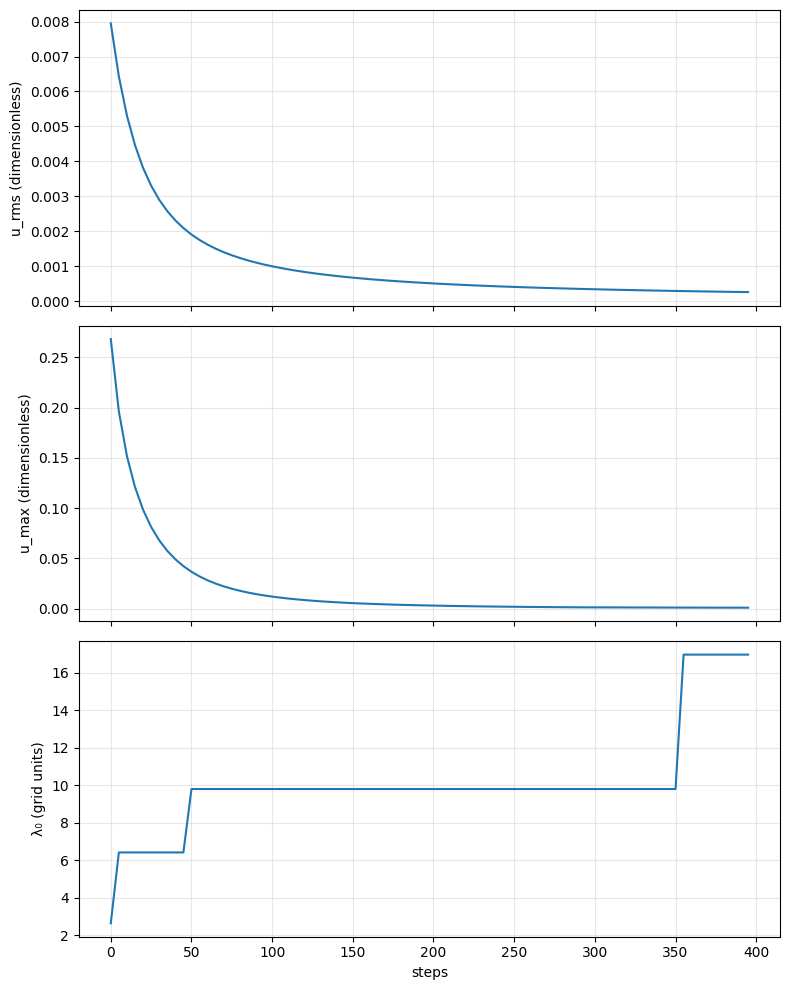

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Utilities -----
def initialize_u(D, N, seed=0):
    rng = np.random.default_rng(seed)
    u = np.zeros([N]*D, dtype=np.float32)
    center = tuple([N//2]*D)
    u[center] = 1.0
    u += 0.01 * rng.standard_normal([N]*D).astype(np.float32)
    return u

def measure_lambda(u):
    F = np.fft.fftn(u)
    F.flat[0] = 0  # remove DC
    P = np.abs(F)**2
    P = np.fft.fftshift(P)
    k_axes = [np.fft.fftshift(np.fft.fftfreq(n)) for n in u.shape]
    K = np.meshgrid(*k_axes, indexing='ij')
    k_mag = np.sqrt(sum(Ki**2 for Ki in K))
    peak_idx = np.unravel_index(np.argmax(P), P.shape)
    k_peak = k_mag[peak_idx]
    return 1.0 / k_peak if k_peak > 0 else np.inf

def spectral_laplacian(shape):
    k_axes = [np.fft.fftfreq(n) for n in shape]
    K = np.meshgrid(*k_axes, indexing='ij')
    k2 = np.zeros(shape, dtype=np.float64)
    for Ki in K:
        k2 += Ki**2
    return - (2*np.pi)**2 * k2

# ----- Rescaled evolution: u = s / S0 -----
def evolve_rescaled(
    D=4, N=24, alpha=0.2, beta=0.005, gamma=1e-5,
    S0=50.0, steps=400, sample_every=5, seed=0, cfl=0.15
):
    # Effective nonlinear strengths at the large physical amplitude S0
    beta_eff = beta * (S0**2)
    gamma_eff = gamma * (S0**4)

    u = initialize_u(D, N, seed=seed)
    shape = u.shape
    lap_op = spectral_laplacian(shape)

    # CFL-safe dt for semi-implicit diffusion
    kmax2 = np.max(-lap_op)
    dt = float(cfl / (alpha * max(1e-12, kmax2)))
    denom = (1.0 - dt * alpha * lap_op)

    u_rms_series, u_max_series, lam_series = [], [], []
    for t in range(steps):
        # Nonlinear terms in u
        nl = - beta_eff * (u**3) - gamma_eff * (u**5)

        # Semi-implicit update
        Fu = np.fft.fftn(u)
        Fnl = np.fft.fftn(nl)
        Fu_new = (Fu + dt * Fnl) / denom
        u = np.fft.ifftn(Fu_new).real.astype(np.float32)

        # Remove mean
        u -= u.mean()

        # Optional: dynamic renorm to keep RMS ~ O(1)
        urms = np.sqrt(np.mean(u**2))
        if urms > 3.0:  # keep u in a comfortable band
            u /= urms

        if not np.isfinite(u).all():
            raise RuntimeError("Non-finite values encountered.")

        if (t+1) % sample_every == 0:
            u_rms_series.append(float(np.sqrt(np.mean(u**2))))
            u_max_series.append(float(np.max(np.abs(u))))
            lam_series.append(float(measure_lambda(u)))

    # Convert u stats back to physical s by multiplying with S0 if needed:
    # s_rms = S0 * np.array(u_rms_series); s_max = S0 * np.array(u_max_series)
    return np.array(u_rms_series), np.array(u_max_series), np.array(lam_series), dt, beta_eff, gamma_eff

# ----- Run and plot -----
u_rms, u_max, lam, dt, beff, geff = evolve_rescaled(D=4, N=24, alpha=0.2, beta=0.005, gamma=1e-5, S0=50.0, steps=400, sample_every=5, seed=0)

ts = np.arange(len(u_rms)) * 5
print(f"dt: {dt:.3e}, beta_eff: {beff:.3e}, gamma_eff: {geff:.3e}")

fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
axs[0].plot(ts, u_rms); axs[0].set_ylabel('u_rms (dimensionless)')
axs[1].plot(ts, u_max); axs[1].set_ylabel('u_max (dimensionless)')
axs[2].plot(ts, lam);   axs[2].set_ylabel('λ₀ (grid units)'); axs[2].set_xlabel('steps')
for ax in axs: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
